<a href="https://colab.research.google.com/github/eliabrodsky/la_data/blob/main/Hospital_Analysis_VBC_EB_Sept_2026_new4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Louisiana Rural Hospital Sustainability, VBC and Shared EHR

1) Segment Louisiana's 64 rural hospitals on financial position,
2) assess which hospital can benefit from entering value-based payment arrangements,
2) identify which hospitals would gain most from a shared Epic instance.

**Data:** CMS Hospital Provider Cost Reports (HCRIS, form CMS-2552-10), FY2021–FY2023,
with the LIHNC roster and the Epic state instance pipeline. Also uses RHTLA.net data on various factors and geography.

---
# 1 &nbsp; Logic of the analysis

## The starting point

LIHNC is a new network of 24 hospitals
Separately, a set of hospitals has engaged with the state Epic instance.
Both groups formed through factors we cannot observe directly: relationships, board decisions, existing referral ties, etc.

The premise of this analysis is that financial position drives these decisions. A hospital under pressure has more to gain from a network, and a hospital with capital has more ability to fund an EHR build. If that premise holds, the financial data will sort hospitals into groups that line up with LIHNC membership and Epic interest.

## What the analysis tests

**Do financial groups exist?** Cluster the hospitals on cost report data and test whether the resulting groups survive resampling.

**Do those groups explain LIHNC and Epic?** Predict membership in each program from financial features alone, and compare against the base rate.

**If not, what does?** Screen the non-financial variables available, and specify what would be needed to answer the question properly.

## What drives a rural hospital's financial position

Financial data shows variability across 3 types of hospitals:

**Reimbursement class.** A Critical Access Hospital (CAH) is paid close to cost. An IPPS hospital receives a fixed price per case.

**Ownership structure.** A parish hospital district holds its own cash. A hospital inside a corporate system has cash moved to the parent org. The balance sheet reports this arrangement.

**Operating performance.** What remains once the first two are accounted for.

Value-based care participation depends on a fourth thing, independent of these: control of primary care billing. Medicare attributes a patient to whoever bills their
primary care visits, so a hospital with no employed primary care providers brings no attributable lives, whatever its size or solvency.

## How the analysis proceeds

| Section | Purpose |
|---|---|
| **2 Load** | Build a three-year panel and derive comparable ratios |
| **3 Explore** | Establish which metrics are comparable across hospitals |
| **4 Cluster** | Find financial groups and test whether they hold |
| **5 Interpret** | Test the groups against LIHNC and Epic membership |
| **6 Explain** | Screen alternative explanations and score shared-EHR benefit |
| **7 Place** | Test whether rurality and population explain the grouping |

## Two properties of the data that shape the method

**Position moves year to year.** Segments assigned from a single year hold across three
years for about half of these hospitals. Cost-settled hospitals swing with settlement
timing. Features are built as level, slope and volatility across all three years.

**Structure contaminates the balance sheet.** Reimbursement class and ownership enter as
stratification variables. Comparisons are made within them, and they stay out of the
clustering inputs.

## Definitions

| Term | Meaning here |
|---|---|
| **Rural hospital** | The 64-hospital universe with a Medicare cost report, from the CMS CAH list and the LDH rural designation lists |
| **Reimbursement class** | Medicare class: CAH, IPPS, SCH, RRC, REH |
| **Ownership stratum** | Type of Control from Worksheet S-2, collapsed to Government, Nonprofit, Proprietary |
| **VBC potential** | Risk-bearing capacity, operating performance, and attributable primary care lives. All three required |
| **Shared EHR benefit** | Implementation cost relative to the hospital's revenue and its clinical volume |

---
# 2 &nbsp; Loading the data

## 2.1 &nbsp; Environment

In [1]:
# SETUP
# Everything the notebook needs, imported once. Plot defaults are set here so
# every figure downstream looks the same without repeating the styling.

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal, linregress
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Environment ready.')

Environment ready.


## 2.2 &nbsp; Source files

3 annual CMS cost report public use files, read directly from GitHub. 2021-2023

`rural_ccn.csv` defines the 64-hospital rural universe and carries the LIHNC and Epic pipeline flags. It also maps filing names to working names, since hospitals file under legal entities: Prevost is West Ascension, Richland Parish Hospital Service District is Richardson, Riverland is Trinity.

In [2]:
# WHERE THE DATA LIVES
# Three annual CMS cost report files plus a crosswalk, read straight from GitHub.
# Nothing to upload; the notebook runs from a clean Colab session.
# The probe pulls 5 rows first so a broken path fails immediately rather than
# after three full downloads.

BASE = 'https://raw.githubusercontent.com/eliabrodsky/la_data/main/'

FILES = {
    2021: BASE + 'CostReport_2021_Final.csv',
    2022: BASE + 'CostReport_2022_Final.csv',
    2023: BASE + 'CostReport_2023_Final.csv',
}

CROSSWALK = BASE + 'rural_ccn.csv'

probe = pd.read_table(FILES[2023], sep=',', header=0, nrows=5, low_memory=False)
print(f'Source reachable. {probe.shape[1]} columns per annual file.')
probe.head()

Source reachable. 117 columns per annual file.


,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,...,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
0,747534,110130,IRWIN COUNTY HOSPITAL,710 NORTH IRWIN AVENUE,OCILLA,GA,31774,IRWIN,99911.0,R,STH,1,9,12/01/2022,01/31/2023,97.15,NaN,NaN,2.0,5.0,...,61.0,0.0496,NaN,NaN,1892400.0,4398064.0,6290464.0,4732674.0,1557790.0,3033643.0,-1475853.0,227033.0,-1248820.0,NaN,-1248820.0,NaN,NaN,NaN,NaN,NaN
1,748262,144042,LAKE BEHAVIORAL HOSPITAL,2615 WASHINGTON ST,WAUKEGAN,IL,60085,LAKE,29404.0,U,PH,4,5,10/01/2022,12/31/2022,227.95,NaN,NaN,613.0,391.0,...,NaN,NaN,NaN,NaN,24175458.0,960619.0,25136077.0,15351779.0,9784298.0,8585822.0,1198476.0,1434403.0,2632879.0,NaN,2632879.0,NaN,NaN,NaN,NaN,NaN
2,748457,43036,EVEREST REHABILITATION HOSPITAL BENT,4313 S PLEASANT CROSSING BLVD,ROGERS,AR,72758-1347,BENTON,22220.0,U,RH,5,6,01/01/2023,02/28/2023,74.54,NaN,NaN,524.0,10.0,...,NaN,NaN,NaN,NaN,2948358.0,34173.0,2982531.0,1532078.0,1450453.0,2447938.0,-997485.0,478980.0,-518505.0,NaN,-518505.0,NaN,NaN,NaN,NaN,NaN
3,748589,454155,OCEANS BEHAVIORAL HOSPITAL CORPUS CH,600 ELIZABETH ST BUILDING B 4TH FLO,CORPUS CHRISTI,TX,78404,NUECES,18580.0,U,PH,4,4,11/17/2022,12/31/2022,68.01,NaN,NaN,64.0,NaN,...,NaN,NaN,NaN,NaN,1703505.0,NaN,1703505.0,441744.0,1261761.0,3445228.0,-2183467.0,170.0,-2183297.0,NaN,-2183297.0,NaN,NaN,NaN,NaN,NaN
4,748617,144043,MONTROSE BEHAVIORAL HEALTH HOSPITAL,4720 NORTH CLARENDON AVENUE,CHICAGO,IL,60640-5122,NaN,NaN,NaN,PH,4,3,10/03/2022,12/31/2022,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.3 &nbsp; Filter to Louisiana and derive the ratio set

Per-day ratios divide by the actual number of days in the reporting period. Cost reports
do not all cover a full year. Six Louisiana reports cover under 330 days and one covers
32 days, where an annual denominator would report 5,140 days of cash on hand in place
of 442.

In [3]:
# LOAD ONE YEAR AND BUILD THE RATIOS
# Each national file is filtered to Louisiana, then five standard ratios are
# derived. CONTROL translates the numeric ownership code into readable labels.
#
# THE IMPORTANT PART: per-day ratios divide by the ACTUAL days in the reporting
# period, not 365. Cost reports are not all full years. One Louisiana hospital
# filed a 32-day period before converting to Rural Emergency Hospital status.
# Dividing its cash by a full year of expense would report 5,140 days of cash
# on hand instead of the true 442. Depreciation is removed from the expense
# base because it is a book entry, not cash leaving the building.

CONTROL = {
    1: 'Nonprofit-Church',       2: 'Nonprofit-Other',
    3: 'Proprietary-Individual', 4: 'Proprietary-Corp',
    5: 'Proprietary-Partnership', 6: 'Proprietary-Other',
    7: 'Gov-Federal',            8: 'Gov-City-County',
    9: 'Gov-County',            10: 'Gov-State',
    11: 'Gov-Hospital District', 12: 'Gov-City',
    13: 'Gov-Other',
}


def load_year(year, url):
    """Read one annual cost report file, keep Louisiana, derive the ratio set."""
    d = pd.read_table(url, sep=',', header=0, low_memory=False)
    d = d[d['State Code'] == 'LA'].copy()

    def col(name):
        if name not in d.columns:
            return pd.Series(np.nan, index=d.index)
        return pd.to_numeric(d[name], errors='coerce')

    begin  = pd.to_datetime(d['Fiscal Year Begin Date'], errors='coerce')
    end    = pd.to_datetime(d['Fiscal Year End Date'],   errors='coerce')
    period = (end - begin).dt.days.clip(lower=1)

    cash = col('Cash on Hand and in Banks').fillna(0) + col('Temporary Investments').fillna(0)
    opex = col('Less Total Operating Expense')
    dep  = col('Depreciation Cost').fillna(0)
    npr  = col('Net Patient Revenue')
    oth  = col('Total Other Income').fillna(0)

    out = pd.DataFrame({
        'fy':          year,
        'ccn':         d['Provider CCN'].astype(str).str.zfill(6),
        'hospital':    d['Hospital Name'].str.strip(),
        'city':        d['City'].str.strip().str.title(),
        'hcris_class': d['CCN Facility Type'],
        'control':     pd.to_numeric(d['Type of Control'], errors='coerce').map(CONTROL),
        'fy_days':     period,
        'npr':         npr,
        'beds':        col('Number of Beds'),
        'fte':         col('FTE - Employees on Payroll'),
    })

    # Liquidity: cash relative to daily cash operating expense, depreciation removed
    out['days_cash']     = (cash / ((opex - dep) / period)).where((opex - dep) > 0)

    # Capital structure
    out['equity_ratio']  = (col('Total Fund Balances') / col('Total Assets')
                            ).where(col('Total Assets') > 0)
    out['current_ratio'] = (col('Total Current Assets') / col('Total Current Liabilities')
                            ).where(col('Total Current Liabilities') > 0)

    # Profitability: on patient care alone, and on the bottom line
    out['pt_svc_margin'] = (col('Net Income from Service to Patients') / npr).where(npr > 0)
    out['total_margin']  = (col('Net Income') / (npr + oth)).where((npr + oth) > 0)

    print(f'  FY{year}: {len(out)} Louisiana hospitals')
    return out


print('Loading annual cost report files')
panel = pd.concat([load_year(y, u) for y, u in FILES.items()], ignore_index=True)

Loading annual cost report files
  FY2021: 209 Louisiana hospitals
  FY2022: 209 Louisiana hospitals
  FY2023: 205 Louisiana hospitals


## 2.4 &nbsp; Restrict to the rural universe and assign ownership stratum

COMMENT:
The 15 for-profit hospitals are identified using the CMS Type of Control field on Worksheet S-2, line 21, which categorizes hospitals as government, nonprofit, or proprietary; proprietary includes codes 3–6 (individual, corporation, partnership, and other). Of the 64 hospitals, 15 fall into this category, with 14 classified as Proprietary-Corporate and one, DeQuincy Memorial, as Proprietary-Individual. This stratum largely consists of hospitals owned by multi-state operators, where cash is typically held in a corporate treasury and the hospital-level cost report reflects only the local operating account, which is often close to zero; median days cash is 4.5 compared with approximately 120 days for parish hospital districts. The equity data tells a similar story: median equity ratio is negative 6%, with several hospitals deeply negative, including Bienville at -113% and Northern Louisiana at -95%, reflecting intercompany debt owed to the parent rather than necessarily indicating financial distress. Minden is the extreme example, reporting -159 days cash because its local account is overdrawn against the parent—an expected feature of a swept-cash structure but a very different signal from a standalone hospital with negative cash. This is why liquidity is incorporated into the analysis as a within-stratum percentile rank rather than a raw days-cash measure; otherwise, a functioning referral center such as Minden could rank below hospitals experiencing genuine financial distress. The stratum is also not uniformly weak: Avoyelles has 78.7 days cash and a 10% total margin, while Byrd has 20.9 days cash and a 12% margin. It also includes some of the larger and more strategically important rural facilities, including Glenwood, the only proprietary LIHNC member at 278 beds, as well as Northern Louisiana and Minden, two of the three rural referral centers. For the VBC work, it is worth flagging that 14 of the 15 are outside LIHNC, making this the largest pool of unrecruited capacity if the network expands—and because these hospitals are part of larger corporate systems, participation decisions will generally be made by their corporate parents rather than local boards.

In [4]:
# NARROW TO THE 64 RURAL HOSPITALS AND GROUP BY OWNERSHIP
# The crosswalk defines which hospitals count as rural and carries the LIHNC and
# Epic flags. It also fixes name mismatches: hospitals file under legal entity
# names that differ from how anyone refers to them (Prevost is West Ascension,
# Richland Parish Hospital Service District is Richardson, Riverland is Trinity).
#
# The 13 ownership codes collapse to three groups. Every financial comparison
# later happens WITHIN these groups, for the reason the next section shows.

xwalk = pd.read_table(CROSSWALK, sep=',', header=0, dtype=str)
xwalk['ccn'] = xwalk['ccn'].str.zfill(6)

panel = panel[panel['ccn'].isin(set(xwalk['ccn']))].copy()

panel['stratum'] = panel['control'].map(
    lambda c: 'Government'  if str(c).startswith('Gov')
    else     ('Proprietary' if str(c).startswith('Proprietary')
    else      'Nonprofit')
)

print(f"{len(panel)} hospital-years  |  {panel['ccn'].nunique()} hospitals  "
      f"|  FY{panel['fy'].min()}-FY{panel['fy'].max()}")
print()
print('Ownership stratum, most recent year')
print(panel[panel['fy'] == panel['fy'].max()]['stratum'].value_counts().to_string())

191 hospital-years  |  64 hospitals  |  FY2021-FY2023

Ownership stratum, most recent year
stratum
Government     37
Proprietary    15
Nonprofit      12


---
# 3 &nbsp; Exploratory analysis

Establishes which metrics are comparable across hospitals, which determines what the
clustering model may contain.

## 3.1 &nbsp; Distribution by ownership

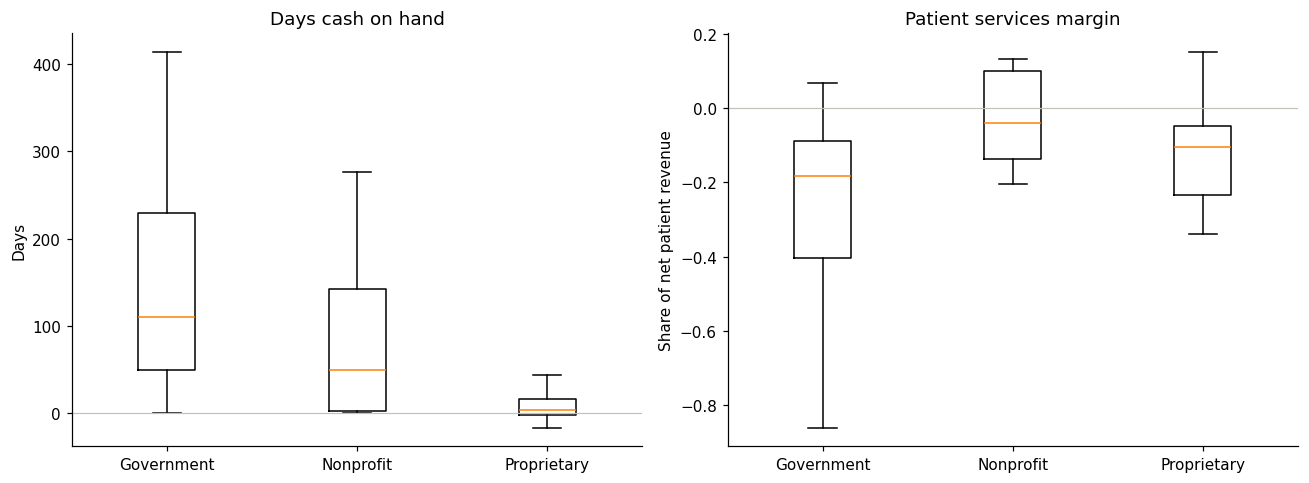

                       days_cash          equity_ratio        total_margin       
                            size   median         size median         size median
control                                                                          
Gov-Hospital District         30  120.826           30  0.717           30  0.058
Proprietary-Corp              14    7.534           14 -0.014           14 -0.042
Nonprofit-Other                9   21.122            9  0.671            9  0.100
Nonprofit-Church               3  106.656            3  0.798            3  0.123
Gov-City-County                2  181.448            2  0.620            2  0.114
Gov-City                       2   49.036            2  0.764            2  0.044
Gov-State                      1    0.000            1    NaN            1    NaN
Gov-Other                      1  198.408            1  0.648            1  0.178
Gov-County                     1  413.888            1  0.971            1  0.108
Proprietary-Indi

In [5]:
# LOOK AT THE DATA BEFORE TESTING ANYTHING
# Boxplots of the two key metrics by ownership. If liquidity splits cleanly by
# who owns the hospital, then comparing a parish district to a for-profit on
# cash is comparing two accounting setups, not two levels of health.

latest = panel[panel['fy'] == panel['fy'].max()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, metric, title in zip(
        axes,
        ['days_cash', 'pt_svc_margin'],
        ['Days cash on hand', 'Patient services margin']):

    order = ['Government', 'Nonprofit', 'Proprietary']
    data = [latest.loc[latest['stratum'] == s, metric].dropna() for s in order]
    ax.boxplot(data, tick_labels=order, showfliers=False)
    ax.set_title(title)
    ax.axhline(0, color='#c3c2b7', linewidth=0.8)

axes[0].set_ylabel('Days')
axes[1].set_ylabel('Share of net patient revenue')
plt.tight_layout()
plt.show()

print(latest.groupby('control')[['days_cash', 'equity_ratio', 'total_margin']]
      .agg(['size', 'median']).round(3)
      .sort_values(('days_cash', 'size'), ascending=False).to_string())

## 3.2 &nbsp; Confound test

Kruskal-Wallis tests whether distributions differ across groups without assuming
normality, which these skewed ratios violate.

In [6]:
# IS THE METRIC COMPARABLE ACROSS HOSPITALS, OR IS IT MEASURING STRUCTURE?
# Kruskal-Wallis asks whether the distributions differ across groups. It does
# not assume a bell curve, which matters because these ratios are badly skewed.
#
# Two metrics tested against two groupings. A metric that differs sharply by
# ownership cannot be compared across ownership types without adjustment.

print('Kruskal-Wallis tests')
print('-' * 66)

for metric in ['days_cash', 'pt_svc_margin']:
    for grouping in ['control', 'hcris_class']:
        groups = [g[metric].dropna().values
                  for _, g in latest.groupby(grouping)
                  if g[metric].notna().sum() >= 3]
        h, p = kruskal(*groups)

        if p < 0.01:
            verdict = 'CONFOUNDED'
        elif p < 0.10:
            verdict = 'borderline'
        else:
            verdict = 'clear'

        print(f'{metric:16s} ~ {grouping:12s}   H = {h:6.2f}   p = {p:.4f}   {verdict}')

Kruskal-Wallis tests
------------------------------------------------------------------
days_cash        ~ control        H =  20.42   p = 0.0001   CONFOUNDED
days_cash        ~ hcris_class    H =   1.53   p = 0.2160   clear
pt_svc_margin    ~ control        H =   7.74   p = 0.0518   borderline
pt_svc_margin    ~ hcris_class    H =   0.20   p = 0.6530   clear


### Result

**Days cash on hand differs by ownership** (p = 0.0001) and not by Medicare class
(p = 0.22). Government hospital districts hold their own cash at a median near 120 days.
Proprietary corporations sweep it to a parent and report a median near 8 days, often
with negative equity. That gap measures a treasury arrangement.

**Patient services margin is borderline on ownership** (p = 0.05) and clear on Medicare
class, so it holds as a direct cross-hospital comparison.

Liquidity enters the model as a within-stratum percentile rank. Operating margin enters
as a raw value.

In [7]:
# FIX THE CONFOUND: RANK WITHIN OWNERSHIP GROUP
# Days cash failed the test above, so it enters the model as a percentile rank
# inside its own ownership group. A district hospital is now measured against
# other districts, a for-profit against other for-profits. Raw dollars are kept
# for reporting but never used in the model.

for col in ['days_cash', 'equity_ratio']:
    panel[f'{col}_pct'] = panel.groupby(['fy', 'stratum'])[col].rank(pct=True)

print('Raw value vs within-stratum rank')
print(panel[['hospital', 'fy', 'stratum', 'days_cash', 'days_cash_pct']]
      .head(8).round(3).to_string(index=False))

Raw value vs within-stratum rank
                           hospital   fy    stratum  days_cash  days_cash_pct
                 ST MARTIN HOSPITAL 2021 Government      0.196          0.077
     POINTE COUPEE GENERAL HOSPITAL 2021 Government     52.993          0.231
            HARDTNER MEDICAL CENTER 2021 Government     65.803          0.256
                 OCHSNER BAYOU  LLC 2021  Nonprofit      0.427          0.222
LALLIE KEMP REGIONAL MEDICAL CENTER 2021 Government    -30.296          0.026
         NORTH CADDO MEDICAL CENTER 2021 Government    199.502          0.641
 CHRISTUS COUSHATTA HEALTH CARE CTR 2021  Nonprofit      4.851          0.333
            JACKSON PARISH HOSPITAL 2021 Government    216.979          0.692


## 3.3 &nbsp; Direction of travel

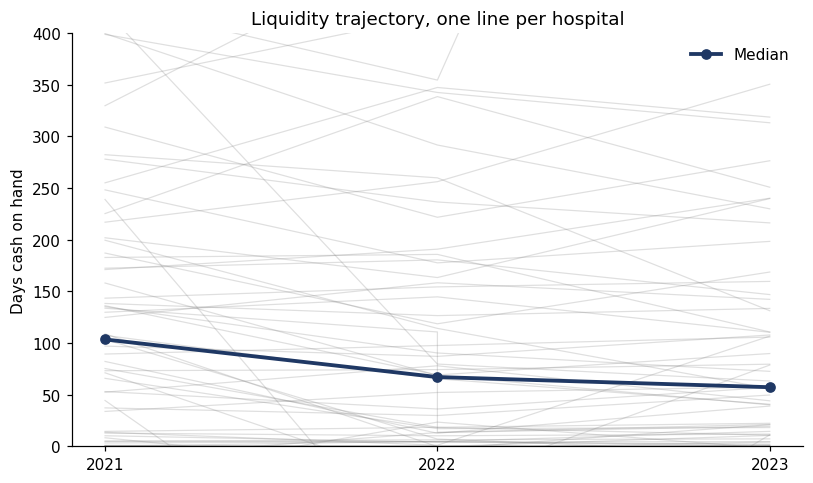

       n  days_cash  pt_svc_margin  total_margin  under_60_days  negative_margin
fy                                                                              
2021  63    103.453         -0.143         0.103             24               11
2022  64     67.039         -0.137         0.058             31               18
2023  64     57.217         -0.147         0.061             33               22


In [8]:
# ARE THINGS GETTING BETTER OR WORSE?
# One faint line per hospital across three years, with the sector median on top.
# What to look for: whether the median moves, and whether the movement is spread
# across everyone or concentrated in part of the group. Those two patterns mean
# very different things about who is actually at risk.

fig, ax = plt.subplots(figsize=(7.5, 4.5))

for _, g in panel.groupby('ccn'):
    if g['days_cash'].notna().sum() >= 2:
        ax.plot(g['fy'], g['days_cash'], color='gray', alpha=0.25, linewidth=0.8)

median = panel.groupby('fy')['days_cash'].median()
ax.plot(median.index, median.values, color='#1F3864', linewidth=2.5,
        marker='o', label='Median')

ax.set_ylim(0, 400)
ax.set_xticks(sorted(panel['fy'].unique()))
ax.set_ylabel('Days cash on hand')
ax.set_title('Liquidity trajectory, one line per hospital')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

trend = panel.groupby('fy').agg(
    n=('ccn', 'size'),
    days_cash=('days_cash', 'median'),
    pt_svc_margin=('pt_svc_margin', 'median'),
    total_margin=('total_margin', 'median'),
    under_60_days=('days_cash', lambda s: int((s < 60).sum())),
    negative_margin=('total_margin', lambda s: int((s < 0).sum())),
).round(3)

print(trend.to_string())

## 3.4 &nbsp; Hospital-level features

One row per hospital, with three views of each metric: **level**, **slope** and
**volatility**. This distinguishes a hospital that is stable and weak from one that is
deteriorating.

In [9]:
# ONE ROW PER HOSPITAL INSTEAD OF ONE ROW PER YEAR
# Three views of each metric:
#   level       where the hospital stands in the most recent year
#   slope       which direction it has moved across three years
#   volatility  how much it swings year to year
#
# WHY: a single year is unreliable here. Assigning a group from one year holds
# across all three years for only about half these hospitals, because cost-settled
# hospitals swing with settlement timing. Building the trajectory into the
# features is what stops the model chasing noise.

def slope(group, column):
    """Least-squares slope across available years. NaN if fewer than 2 points."""
    s = group.dropna(subset=[column])
    if len(s) < 2:
        return np.nan
    return linregress(s['fy'], s[column]).slope


METRICS = ['days_cash_pct', 'equity_ratio_pct', 'pt_svc_margin',
           'total_margin', 'days_cash', 'npr', 'beds', 'fte']

rows = []
for ccn, g in panel.groupby('ccn'):
    g = g.sort_values('fy')
    last = g.iloc[-1]

    row = {
        'ccn':         ccn,
        'hospital':    last['hospital'],
        'stratum':     last['stratum'],
        'control':     last['control'],
        'hcris_class': last['hcris_class'],
        'n_years':     len(g),
    }
    for m in METRICS:
        row[f'{m}_lvl']   = last[m]
        row[f'{m}_slope'] = slope(g, m)
        row[f'{m}_vol']   = g[m].std() if g[m].notna().sum() >= 2 else np.nan

    rows.append(row)

feat = pd.DataFrame(rows)
print(f'{len(feat)} hospitals, {feat.shape[1]} engineered columns')
feat.head()

64 hospitals, 30 engineered columns


,ccn,hospital,stratum,control,hcris_class,n_years,days_cash_pct_lvl,days_cash_pct_slope,days_cash_pct_vol,equity_ratio_pct_lvl,equity_ratio_pct_slope,equity_ratio_pct_vol,pt_svc_margin_lvl,pt_svc_margin_slope,pt_svc_margin_vol,total_margin_lvl,total_margin_slope,total_margin_vol,days_cash_lvl,days_cash_slope,days_cash_vol,npr_lvl,npr_slope,npr_vol,beds_lvl,beds_slope,beds_vol,fte_lvl,fte_slope,fte_vol
0,190007,NATCHITOCHES REGIONAL MEDICAL CENTER,Government,Gov-Hospital District,STH,3,0.162162,0.004158,0.018479,0.472222,-0.033120,0.066528,-0.140274,0.005439,0.042357,0.019769,-0.015674,0.056681,22.286451,3.927753,3.927818,101531512.0,9788748.5,1.117306e+07,81.0,0.0,0.000000,448.41,-17.115,24.127209
1,190013,WEST CALCASIEU-CAMERON HOSPITAL,Government,Gov-Hospital District,STH,3,0.108108,-0.010049,0.023647,0.194444,0.020299,0.043194,-0.585312,-0.049458,0.062990,-0.021433,-0.002303,0.032834,11.817556,-0.481716,1.311346,60830990.0,-58564.5,7.215452e+05,107.0,0.0,0.000000,481.43,-41.185,41.553587
2,190014,OCHSNER ST. MARY,Proprietary,Proprietary-Corp,STH,3,0.533333,0.000000,0.085862,0.461538,-0.197802,0.390123,-0.227476,-0.085698,0.146569,-0.101737,-0.073771,0.163338,4.511933,-0.252201,0.382597,36229926.0,-1205582.0,1.494412e+06,105.0,-12.0,13.856406,NaN,15.620,11.045008
3,190017,OPELOUSAS GENERAL HOSPITAL,Government,Gov-City-County,STH,3,0.270270,0.032571,0.034853,0.305556,-0.039530,0.076962,-0.182694,-0.001065,0.031446,-0.044522,-0.025735,0.026353,49.663317,6.231551,10.028684,157763671.0,3394469.0,8.837719e+06,151.0,0.0,0.000000,902.07,-31.990,35.445516
4,190020,LANE REGIONAL MEDICAL CENTER,Government,Gov-Hospital District,STH,3,0.432432,-0.027374,0.068338,0.222222,-0.170940,0.172437,-0.494640,-0.118021,0.122012,-0.049497,-0.017480,0.018684,89.821937,-23.166475,34.325943,75403257.0,-803616.0,8.226661e+05,109.0,0.0,0.000000,134.71,-3.590,4.145375


## 3.5 &nbsp; Feature selection

With 64 hospitals the model carries six features, one from each block: liquidity,
capital structure, profitability, scale. Extreme values are winsorized at the 5th and
95th percentiles, since the outliers here are real hospitals.

In [10]:
# PICK SIX FEATURES, NOT FIFTEEN
# With 64 hospitals the model can carry roughly six variables before it starts
# fitting noise. Several candidates measure the same underlying thing, so one is
# kept from each block: liquidity, capital structure, profitability, size.
#
# Winsorizing clips the most extreme 5% at each end rather than deleting those
# rows. The outliers here are real hospitals, not data errors.

FEATURES = [
    'days_cash_pct_lvl',     # liquidity, ranked within ownership stratum
    'equity_ratio_pct_lvl',  # capital structure, ranked within stratum
    'pt_svc_margin_lvl',     # operating performance, where it stands
    'pt_svc_margin_slope',   # operating performance, where it is heading
    'total_margin_lvl',      # bottom line including non-patient revenue
    'npr_lvl',               # scale
]

X = feat[FEATURES].copy()
X['npr_lvl'] = np.log10(X['npr_lvl'].clip(lower=1))

complete = X.notna().all(axis=1)
Xc = X[complete].copy()

for c in Xc.columns:
    lo, hi = Xc[c].quantile([0.05, 0.95])
    Xc[c] = Xc[c].clip(lo, hi)

Xs = StandardScaler().fit_transform(Xc)
sub = feat[complete].reset_index(drop=True)

print(f'{complete.sum()} of {len(feat)} hospitals complete on all six features')
print()
print('Spearman correlation')
print(pd.DataFrame(Xs, columns=FEATURES).corr(method='spearman').round(2).to_string())

60 of 64 hospitals complete on all six features

Spearman correlation
                      days_cash_pct_lvl  equity_ratio_pct_lvl  pt_svc_margin_lvl  pt_svc_margin_slope  total_margin_lvl  npr_lvl
days_cash_pct_lvl                  1.00                  0.15              -0.01                -0.05              0.08    -0.34
equity_ratio_pct_lvl               0.15                  1.00               0.39                 0.17              0.45    -0.10
pt_svc_margin_lvl                 -0.01                  0.39               1.00                 0.48              0.48     0.12
pt_svc_margin_slope               -0.05                  0.17               0.48                 1.00              0.44    -0.04
total_margin_lvl                   0.08                  0.45               0.48                 0.44              1.00    -0.03
npr_lvl                           -0.34                 -0.10               0.12                -0.04             -0.03     1.00


---
# 4 &nbsp; Clustering

## 4.1 &nbsp; Method

**Ward-linkage hierarchical clustering**, deterministic and requiring no commitment to
a number of groups in advance. K-means runs alongside as a cross-check.

**Bootstrap stability** decides how many groups are reported:

1. Resample hospitals with replacement and cluster the resample
2. Assign all original hospitals to the nearest resulting cluster centre
3. Measure Jaccard overlap between each original cluster and its best match
4. Repeat 400 times and average

Thresholds: **0.60 and above is stable**, **0.75 and above is highly stable**, below
0.50 indicates an artefact of the sample. A solution is reported only when every
cluster clears 0.60.

In [11]:
# CLUSTERING, AND THE TEST THAT DECIDES WHETHER TO BELIEVE IT
#
# ward()        groups hospitals by similarity. Deterministic, and it does not
#               require guessing the number of groups in advance.
#
# clusterboot() the honesty check. With 64 hospitals it is easy to produce
#               attractive groups that fall apart if two hospitals are swapped.
#               So: draw a random sample with replacement, cluster it, assign
#               ALL the original hospitals to the nearest resulting group, and
#               measure the overlap with the original grouping. Repeat 400 times.
#
#               Assigning the original hospitals is the key step. Comparing row
#               numbers instead would cap the score near 0.63, because a bootstrap
#               sample only contains about 63% of the original rows.
#
# Jaccard is that overlap, 0 to 1. Above 0.60 the group is real. Below 0.50 it is
# an accident of this particular sample. A grouping is only reported if EVERY
# group clears 0.60.

def ward(X, k):
    """Ward-linkage flat clustering into k groups."""
    return fcluster(linkage(X, method='ward'), k, criterion='maxclust')


def clusterboot(X, k, n_boot=400, seed=0):
    """Bootstrap cluster stability. Returns base labels and mean Jaccard per cluster."""
    rng = np.random.default_rng(seed)
    base = ward(X, k)
    jaccard = np.zeros((n_boot, k))

    for b in range(n_boot):
        idx = rng.integers(0, len(X), len(X))
        Xb = X[idx]
        labels_b = ward(Xb, k)

        centroids = np.array([Xb[labels_b == c].mean(axis=0) for c in range(1, k + 1)])
        assigned = np.argmin(cdist(X, centroids), axis=1) + 1

        for c in range(1, k + 1):
            original = set(np.where(base == c)[0])
            best = 0.0
            for rc in range(1, k + 1):
                resampled = set(np.where(assigned == rc)[0])
                union = len(original | resampled)
                if union:
                    best = max(best, len(original & resampled) / union)
            jaccard[b, c - 1] = best

    return base, jaccard.mean(axis=0)

## 4.2 &nbsp; Number of groups

In [ ]:
# HOW MANY GROUPS DOES THE DATA ACTUALLY SUPPORT?
# Three checks read together:
#   silhouette  how separated the groups are (0.2-0.3 is weak but present)
#   ARI         whether a second algorithm finds the same groups
#   Jaccard     whether the groups survive resampling  <- this one decides

print(f"{'k':>2}  {'silhouette':>10}  {'ARI vs kmeans':>13}   cluster sizes and stability")
print('-' * 90)

for k in range(2, 6):
    base, jac = clusterboot(Xs, k)
    km = KMeans(n_clusters=k, n_init=25, random_state=0).fit(Xs)
    sizes = np.bincount(base)[1:]

    detail = '   '.join(f'n={s:<3d} J={j:.2f}' for s, j in zip(sizes, jac))
    print(f'{k:>2}  {silhouette_score(Xs, base):>10.3f}  '
          f'{adjusted_rand_score(base, km.labels_):>13.2f}   '
          f'{detail}   mean J = {jac.mean():.3f}')

 k  silhouette  ARI vs kmeans   cluster sizes and stability
------------------------------------------------------------------------------------------


### Result

**Two groups**, stable at roughly 0.65 and 0.73.

From k = 3 upward a four-hospital cluster appears with a Jaccard near 0.38. At k = 4
only the largest cluster clears the threshold and mean stability falls to 0.53.
Silhouettes run 0.20 to 0.24 across the range, consistent with a single split rather
than a graded set of tiers.

In [ ]:
# FIT THE ANSWER THE TEST SUPPORTED: TWO GROUPS
# The dendrogram shows where the data splits. Height of a join is how different
# the two branches are, so the tall join near the top is the main division.

K = 2
sub['cluster'] = ward(Xs, K)

fig, ax = plt.subplots(figsize=(13, 4.5))
dendrogram(linkage(Xs, method='ward'),
           labels=sub['hospital'].values,
           leaf_rotation=90,
           leaf_font_size=6,
           ax=ax)
ax.set_title('Ward linkage, Louisiana rural hospitals')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

---
# 5 &nbsp; Interpretation

## 5.1 &nbsp; Profile of the two groups

In [ ]:
# WHAT DO THE TWO GROUPS ACTUALLY LOOK LIKE?
# Medians in plain units, so the groups can be described to a hospital CEO.

profile_cols = ['days_cash_pct_lvl', 'equity_ratio_pct_lvl', 'pt_svc_margin_lvl',
                'pt_svc_margin_slope', 'total_margin_lvl', 'days_cash_lvl']

print('Cluster profile, medians')
print(sub.groupby('cluster')[profile_cols].median().round(3).to_string())
print()
print('Sizes:', np.bincount(sub['cluster'])[1:])

| | Cluster 1 (n = 27) | Cluster 2 (n = 33) |
|---|---|---|
| Patient services margin | −30% | −8% |
| Direction of travel | worsening | improving |
| Total margin | −4% | +12% |
| Days cash on hand | 39 | 108 |
| Equity percentile within stratum | 0.33 | 0.69 |

Both groups lose money delivering care, which is the standard condition for a Louisiana
rural hospital. The split is the size of the gap and whether it is closing or widening.

## 5.2 &nbsp; What separates them

In [ ]:
# WHAT SEPARATES THEM, AND WHAT THEY ARE NOT
# A two-question decision tree gives the actual dividing rule in readable form.
# The crosstabs then check whether the clustering just rediscovered a label we
# already had. If the groups spread evenly across Medicare class and ownership,
# the split is genuinely new information.

tree = DecisionTreeClassifier(max_depth=2, random_state=0).fit(Xs, sub['cluster'])
print('Split rule')
print(export_text(tree, feature_names=FEATURES))

for col in ['hcris_class', 'stratum']:
    print(f'Cluster by {col}')
    print(pd.crosstab(sub['cluster'], sub[col]).to_string())
    print()

The split runs on total margin and equity rank, and spreads across both Medicare class
and ownership stratum. It is a new grouping, not a restatement of CAH status or of who
owns the hospital.

## 5.3 &nbsp; Testing the premise

The premise from section 1 was that financial position drives who joins LIHNC and who
engages with Epic. Predict membership in each from the financial features alone.
Accuracy at or below the base rate means financial position carries no information
about that grouping.

In [ ]:
# TESTING THE WHOLE PREMISE OF THE ANALYSIS
# The assumption going in was that financial position drives who joined LIHNC and
# who engaged with Epic. Here it gets tested: predict membership using ONLY the
# financial features.
#
# HOW TO READ IT: the base rate is what you would score by always guessing the
# bigger group. If accuracy does not beat the base rate, the financial data tells
# you nothing about that grouping. Cross-validation trains on part of the data and
# tests on the rest, repeatedly, so the score is not just memorisation.

flags = xwalk[['ccn', 'lihnc_member', 'in_epic_pipeline']]
sub = sub.merge(flags, on='ccn', how='left')

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)

targets = {
    'CAH designation': (sub['hcris_class'] == 'CAH').astype(int),
    'LIHNC member':    (sub['lihnc_member'] == 'Yes').astype(int),
    'Epic pipeline':   (sub['in_epic_pipeline'] == 'Yes').astype(int),
}

print(f"{'Grouping':<18}{'base rate':>11}{'CV accuracy':>13}{'lift':>8}   verdict")
print('-' * 72)

for name, y in targets.items():
    base_rate = max(y.mean(), 1 - y.mean())
    acc = cross_val_score(LogisticRegression(C=0.5, max_iter=2000),
                          Xs, y, cv=cv, scoring='accuracy').mean()
    lift = acc - base_rate
    verdict = 'carries signal' if lift > 0.05 else 'no financial signal'
    print(f'{name:<18}{base_rate:>11.2f}{acc:>13.2f}{lift:>+8.2f}   {verdict}')

### Result: the premise fails

**CAH designation is predictable** from financial position, as reimbursement class and
finances are linked.

**LIHNC membership is not. Epic pipeline participation is not.** Both score below the
base rate, so the financial features perform worse than guessing the majority class.

Financial position played no part in determining who joined the network or who entered
the Epic waves. Neither grouping works as a proxy for readiness, and if either program
is meant to reach hospitals under financial pressure, it is not currently selecting
for that.

The question becomes what does explain the grouping.

## 5.4 &nbsp; Scoring VBC potential

Two of the three requirements from section 1 are measurable from cost report data. The
third is measurable from no available dataset and is carried as a blank.

| Axis | Source | Status |
|---|---|---|
| **Risk-bearing capacity** | Liquidity and equity, ranked within ownership stratum | Scored |
| **Operating performance** | Patient services margin, its trend, and total margin | Scored |
| **Attribution capacity** | Primary care providers billing under the hospital's own TIN, and certified provider-based RHCs | **No data. Requires a survey** |

The axes stay separate. A hospital strong on both scored axes and empty on the third is
not a candidate, and a combined score would conceal that.

In [ ]:
# SCORING VBC READINESS ON THREE AXES
# Two can be measured from cost reports. The third cannot be measured at all yet,
# so it is carried as an explicit blank rather than guessed:
#
#   risk capacity     can the hospital absorb a bad year (cash and equity)
#   operating         does delivering care generate or consume money
#   attribution       how many patients are attributed to it  <- NO DATA
#
# The axes stay separate on purpose. A hospital strong on the first two and empty
# on the third is not a candidate, and a single blended score would hide that.

z = pd.DataFrame(Xs, columns=FEATURES)

sub['risk_capacity']  = z[['days_cash_pct_lvl', 'equity_ratio_pct_lvl']].mean(axis=1)
sub['operating_perf'] = z[['pt_svc_margin_lvl', 'pt_svc_margin_slope',
                           'total_margin_lvl']].mean(axis=1)
sub['attribution']    = np.nan   # awaiting the primary care and billing TIN survey

for c in ['risk_capacity', 'operating_perf']:
    sub[f'{c}_pct'] = sub[c].rank(pct=True).round(2)

fig, ax = plt.subplots(figsize=(7.5, 6))

palette = {1: ('#E24B4A', 'Cluster 1  (n=27)'),
           2: ('#1D9E75', 'Cluster 2  (n=33)')}

for cl, (colour, label) in palette.items():
    s = sub[sub['cluster'] == cl]
    ax.scatter(s['operating_perf'], s['risk_capacity'], c=colour, s=48,
               alpha=0.75, edgecolor='white', linewidth=0.5, label=label)

ax.axhline(0, color='#c3c2b7', linewidth=0.8)
ax.axvline(0, color='#c3c2b7', linewidth=0.8)
ax.set_xlabel('Operating performance  (standardized)')
ax.set_ylabel('Risk-bearing capacity  (within ownership stratum)')
ax.set_title('Two scored axes. The third, attribution, has no data.')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
# EXPORT ONE ROW PER HOSPITAL
# Percentile ranks rather than raw scores, so a hospital's position is reported
# as a rank among peers instead of a false-precision number.

scorecard = (sub[['hospital', 'hcris_class', 'stratum', 'cluster',
                  'risk_capacity_pct', 'operating_perf_pct', 'attribution',
                  'days_cash_lvl', 'pt_svc_margin_lvl', 'total_margin_lvl']]
             .sort_values('operating_perf_pct', ascending=False)
             .round(3))

scorecard.to_csv('la_hospital_scorecard.csv', index=False)
print(f'Wrote la_hospital_scorecard.csv  ({len(scorecard)} hospitals)')

# In Colab: from google.colab import files; files.download('la_hospital_scorecard.csv')

scorecard.head(15)

---
# 6 &nbsp; What explains the grouping

## 6.1 &nbsp; LIHNC and Epic track each other

Financial data does not explain either grouping. Before looking further, test whether
the two groupings explain each other.

In [ ]:
# IF FINANCES DO NOT EXPLAIN EITHER PROGRAM, DO THEY EXPLAIN EACH OTHER?
# Fisher's exact test works on small counts where a chi-square would not.
# The odds ratio says how much more likely a LIHNC member is to also be in the
# Epic pipeline than a non-member.

sub['lihnc'] = (sub['lihnc_member'] == 'Yes').astype(int)
sub['epic']  = (sub['in_epic_pipeline'] == 'Yes').astype(int)

from scipy.stats import fisher_exact

overlap = pd.crosstab(sub['lihnc'], sub['epic'])
overlap.index = ['Not LIHNC', 'LIHNC']
overlap.columns = ['Not in Epic pipeline', 'In Epic pipeline']

odds, p = fisher_exact(overlap.values)

print(overlap.to_string())
print()
print(f'Fisher exact test:  odds ratio = {odds:.2f},  p = {p:.4f}')

### Result

The two groupings are **strongly associated with each other** while neither is
associated with financial position.

A LIHNC member is roughly five to six times more likely to be in the Epic pipeline than
a non-member. Whatever produced the LIHNC roster also produced the Epic pipeline, and it
is not financial.

That is consistent with a relationship-driven mechanism: shared referral patterns, the
same regional hospital association meetings, CEOs who already knew each other, one
hospital recruiting its neighbours. None of those appear in a cost report.

## 6.2 &nbsp; Screening the non-financial variables

Test everything else available for the full universe against LIHNC membership. Size,
staffing, payer mix and market trajectory.

In [ ]:
# SCREEN EVERYTHING ELSE AVAILABLE
# Size, staffing, revenue, liquidity. If none of these separate members from
# non-members either, the driver is something no cost report records.

from scipy.stats import mannwhitneyu

candidates = {
    'Beds':                'beds_lvl',
    'FTE employees':       'fte_lvl',
    'Net patient revenue': 'npr_lvl',
    'Days cash on hand':   'days_cash_lvl',
}

print(f"{'Variable':<36}{'LIHNC median':>16}{'Non-member':>16}{'p':>9}")
print('-' * 78)

for label, v in candidates.items():
    if v not in sub.columns:
        print(f'{label:<36}{"not in feature table":>41}')
        continue
    a = sub.loc[sub['lihnc'] == 1, v].dropna()
    b = sub.loc[sub['lihnc'] == 0, v].dropna()
    if len(a) < 5 or len(b) < 5:
        continue
    _, p = mannwhitneyu(a, b)
    print(f'{label:<36}{a.median():>16,.1f}{b.median():>16,.1f}{p:>9.3f}')

print()
print('LIHNC membership by Medicare class')
print(pd.crosstab(sub['hcris_class'], sub['lihnc_member']).to_string())

### Result

Bed count, staffing and revenue come back null. **Raw days cash on hand does not**:
LIHNC members hold a median of 98 days against 22 for non-members (p = 0.015).

That appears to contradict section 5.3, where financial features could not predict
membership. The next cell resolves it. The model used liquidity *ranked within
ownership stratum*, and the raw difference is a composition effect.

## 6.3 &nbsp; LIHNC is a network of public hospital districts

In [ ]:
# RESOLVING AN APPARENT CONTRADICTION
# Raw days cash DOES differ between LIHNC members and non-members, which seems
# to contradict the earlier finding that financial features predict nothing.
#
# This cell shows why both are true. LIHNC members look more liquid because they
# are overwhelmingly government districts, and districts hold their own cash while
# corporate hospitals sweep it to a parent. Once you rank within ownership group,
# or compare only government hospitals to each other, the difference vanishes.
#
# The network did not recruit hospitals with money. It recruited public entities.

from scipy.stats import fisher_exact

composition = pd.crosstab(sub['stratum'], sub['lihnc_member'])
print('Ownership stratum by LIHNC membership')
print(composition.to_string())

gov_prop = composition.loc[['Government', 'Proprietary']]
_, p_comp = fisher_exact(gov_prop.values)
print(f'\nGovernment vs Proprietary composition, Fisher p = {p_comp:.4f}')

print('\nLiquidity, raw against stratum-adjusted')
for col, label in [('days_cash_lvl', 'Days cash, raw'),
                   ('days_cash_pct_lvl', 'Days cash, within-stratum rank')]:
    a = sub.loc[sub['lihnc_member'] == 'Yes', col].dropna()
    b = sub.loc[sub['lihnc_member'] == 'No',  col].dropna()
    _, p = mannwhitneyu(a, b)
    print(f'  {label:<32}LIHNC = {a.median():>8.2f}   non = {b.median():>8.2f}   p = {p:.3f}')

gov = sub[sub['stratum'] == 'Government']
a = gov.loc[gov['lihnc_member'] == 'Yes', 'days_cash_lvl'].dropna()
b = gov.loc[gov['lihnc_member'] == 'No',  'days_cash_lvl'].dropna()
_, p_gov = mannwhitneyu(a, b)
print(f'\nWithin the Government stratum only (n = {len(a)} vs {len(b)}): '
      f'LIHNC = {a.median():.1f}, non = {b.median():.1f}, p = {p_gov:.3f}')

### Result: ownership is the organizing fact

**21 of 24 LIHNC members are government hospital districts.** One is proprietary,
against 12 proprietary hospitals outside the network (Fisher p = 0.003).

The raw liquidity gap disappears entirely once ownership is accounted for. Within-stratum
rank gives p = 0.95, and comparing only government hospitals to each other gives p = 0.97.
LIHNC members look more liquid because districts hold their own cash while corporate
hospitals sweep it to a parent. The network did not recruit hospitals with money. It
recruited public entities.

That is consistent with everything else here. Public hospital districts share governance
structures, appear before the same parish boards, and have executives who meet through
the same public-sector channels. Membership followed those relationships, not a balance
sheet.

It also identifies the unrecruited population precisely: **the 12 proprietary hospitals
outside LIHNC**, whose participation is decided by a corporate parent rather than a local
board, and who are the financially weakest stratum in the state.

### Result

Nothing in the available data separates members from non-members. Bed count, staffing,
revenue and Medicare class all come back non-significant. Parish Medicaid enrollment
change is the closest, and it does not clear conventional thresholds.

The grouping is not explained by any structural or financial characteristic that a cost
report records. This points at geography and relationships, neither of which is in the
data as it stands.

## 6.4 &nbsp; Who gains most from a shared EHR instance

A separate question from network membership, and one the pipeline data can answer.

Epic implementation is priced largely per provider seat, so the same instance imposes
very different burdens depending on a hospital's size and how much volume it runs
through each provider. Three measures:

- **Cost as a share of net patient revenue** — the affordability question
- **Cost per provider** — whether the hospital is getting standard per-seat pricing
- **Cost per encounter** — how much clinical volume each licensed seat carries

A hospital with high volume per provider extracts more value from each seat. A hospital
paying a large share of its revenue cannot fund the build alone, which is precisely
where a shared instance and subsidy do the most work.

---
# 7 &nbsp; Does location explain the grouping?

Financial position explains neither program. The Louisiana Health Atlas provides
ZIP-level population, rurality, social vulnerability and facility counts, which lets
the geographic hypothesis be tested directly.

## 7.1 &nbsp; Join hospitals to their ZIP

Hospital ZIP codes come from the cost report. Five hospitals file under a PO Box ZIP,
which has no atlas record, so those are remapped to the physical ZIP of the same city.

In [ ]:
# BRING IN WHERE EACH HOSPITAL SITS
# ZIP-level population, rurality, poverty, and facility counts from the Health
# Atlas, joined on the hospital's ZIP from its cost report.
#
# RUCA runs 1 to 10: low is metropolitan, high is small town and isolated.
# Five hospitals file under a PO Box ZIP that has no atlas record, so those are
# remapped to the physical ZIP of the same town.

ATLAS = BASE + 'louisiana_health_atlas_export_zip.csv'

atlas = pd.read_table(ATLAS, sep=',', header=0, low_memory=False)
atlas['zip'] = atlas['ZIP Code'].astype(str).str.zfill(5)
atlas = atlas.drop_duplicates('zip')

# Hospital ZIP from the most recent cost report
zips = pd.read_table(FILES[2023], sep=',', header=0, low_memory=False)
zips = zips[zips['State Code'] == 'LA'].copy()
zips['ccn'] = zips['Provider CCN'].astype(str).str.zfill(6)
zips['zip'] = zips['Zip Code'].astype(str).str.extract(r'(\d{5})')[0]

# PO Box ZIPs have no atlas record. Remap to the physical ZIP of the same city.
PO_BOX = {'70511': '70510',   # Abbeville
          '70562': '70560',   # New Iberia
          '71121': '71220',   # Bastrop
          '70157': '70517',   # Breaux Bridge
          '70308': '70380'}   # Morgan City
zips['zip'] = zips['zip'].replace(PO_BOX)

place = (sub[['ccn', 'hospital', 'cluster', 'lihnc', 'epic']]
         .merge(zips[['ccn', 'zip']], on='ccn', how='left')
         .merge(atlas, on='zip', how='left'))

place['ruca'] = pd.to_numeric(place['Rural Designation (RUCA Category)'], errors='coerce')

print(f'{place["Population"].notna().sum()} of {len(place)} hospitals matched to a ZIP record')
print()
print(place['Classification'].value_counts().to_string())

## 7.2 &nbsp; Place characteristics against each program

RUCA runs 1 to 10. Low values are metropolitan or metro-adjacent, high values are small
town and isolated. Mann-Whitney compares members against non-members on each atlas
variable.

In [ ]:
# DOES PLACE EXPLAIN EITHER PROGRAM?
# Every atlas variable tested against membership in each program.

from scipy.stats import mannwhitneyu

ATLAS_VARS = {
    'Population':                          'ZIP population',
    'ruca':                                'RUCA category',
    'Social Vulnerability (Poverty)':      'Poverty',
    'Social Vulnerability (Food Access)':  'Food access',
    'Transportation (Vehicle Ownership)':  'No vehicle',
    'Diabetes Prevalence':                 'Diabetes prevalence',
    'Broadband Deserts':                   'Broadband desert',
    'Healthcare Facility (Acute)':         'Acute facilities in ZIP',
    'Healthcare Facility (Specialty)':     'Specialty facilities in ZIP',
}

for target, name in [('lihnc', 'LIHNC membership'), ('epic', 'Epic pipeline')]:
    print(f'{name}')
    print(f"{'Variable':<30}{'member':>12}{'non-member':>13}{'p':>9}")
    print('-' * 66)
    for col, label in ATLAS_VARS.items():
        a = place.loc[place[target] == 1, col].dropna()
        b = place.loc[place[target] == 0, col].dropna()
        if len(a) < 5 or len(b) < 5:
            continue
        _, p = mannwhitneyu(a, b)
        mark = '  <<<' if p < 0.05 else ''
        print(f'{label:<30}{a.median():>12,.1f}{b.median():>13,.1f}{p:>9.3f}{mark}')
    print()

### Result

For **LIHNC**, nothing is significant. Population, poverty, food access, vehicle
ownership, diabetes prevalence, broadband and facility counts all come back null.
Community need did not sort hospitals into the network.

For **Epic**, RUCA category separates the groups (p = 0.03). Pipeline hospitals sit at a
median RUCA of 7 against 4 for non-participants. The Epic pipeline reaches further into
isolated Louisiana than the rest of the universe.

## 7.3 &nbsp; Rurality, with the two programs controlling for each other

The two rosters overlap heavily, so a univariate test cannot tell whether rurality acts
on Epic, on LIHNC, or on whatever they share. Fit each program on RUCA with the other
program included.

In [ ]:
# RURALITY, WITH THE TWO PROGRAMS CONTROLLING FOR EACH OTHER
# The two rosters overlap heavily, so a simple test cannot tell whether rurality
# acts on Epic, on LIHNC, or on whatever they share. Putting both in one model
# separates them.
#
# HOW TO READ THE COEFFICIENT: positive means the program reaches MORE isolated
# hospitals as RUCA rises. Negative means it concentrates nearer metro areas.
# The p-value under 0.05 means the pattern is unlikely to be chance.

import statsmodels.api as sm

model_data = place[['ruca', 'lihnc', 'epic']].dropna().astype(float)

print('Epic pipeline ~ RUCA + LIHNC')
X = sm.add_constant(model_data[['ruca', 'lihnc']])
print(sm.Logit(model_data['epic'], X).fit(disp=0).summary2().tables[1].round(3).to_string())

print()
print('LIHNC membership ~ RUCA + Epic')
X = sm.add_constant(model_data[['ruca', 'epic']])
print(sm.Logit(model_data['lihnc'], X).fit(disp=0).summary2().tables[1].round(3).to_string())

print()
print('Participation rate by RUCA band')
place['band'] = pd.cut(place['ruca'], [0, 3, 6, 10],
                       labels=['1-3 metro / adjacent',
                               '4-6 micropolitan',
                               '7-10 small town / isolated'])
print(place.groupby('band', observed=True)
      .agg(n=('epic', 'size'), epic_rate=('epic', 'mean'), lihnc_rate=('lihnc', 'mean'))
      .round(2).to_string())

### Result: the two programs load on rurality in opposite directions

| Program | RUCA coefficient | p |
|---|---|---|
| Epic pipeline | **+0.25** | 0.010 |
| LIHNC membership | **−0.20** | 0.041 |

Epic participation rises with isolation. LIHNC membership falls with it. Each effect
holds with the other program in the model, so this is not the shared driver showing up
twice.

| Location | n | Epic rate | LIHNC rate |
|---|---|---|---|
| Metro or metro-adjacent (RUCA 1–3) | 18 | 17% | **56%** |
| Micropolitan (4–6) | 13 | 38% | 31% |
| Small town or isolated (7–10) | 33 | **45%** | 30% |

Only 1 of 12 hospitals in an urban ZIP is in the Epic pipeline. LIHNC is a
metro-adjacent network; the Epic pipeline reaches outward.

## 7.4 &nbsp; Where the financial clusters sit

Test the place variables against the financial clustering from section 4.

In [ ]:
# WHERE DO THE FINANCIAL GROUPS SIT GEOGRAPHICALLY?
# Same atlas variables, now tested against the clustering from section 4 rather
# than against program membership.

print(f"{'Variable':<30}{'Cluster 1':>12}{'Cluster 2':>12}{'p':>9}")
print('-' * 65)

for col, label in ATLAS_VARS.items():
    a = place.loc[place['cluster'] == 1, col].dropna()
    b = place.loc[place['cluster'] == 2, col].dropna()
    if len(a) < 5 or len(b) < 5:
        continue
    _, p = mannwhitneyu(a, b)
    mark = '  <<<' if p < 0.05 else ''
    print(f'{label:<30}{a.median():>12,.1f}{b.median():>12,.1f}{p:>9.3f}{mark}')

print()
print('Share of hospitals in the weaker cluster, by ZIP population tercile')
place['pop_band'] = pd.qcut(place['Population'], 3, labels=['small', 'mid', 'large'])
print(place.groupby('pop_band', observed=True)
      .agg(n=('cluster', 'size'),
           share_weak=('cluster', lambda s: (s == 1).mean()),
           median_ruca=('ruca', 'median'))
      .round(2).to_string())

### Result: the financially weaker hospitals are in the larger towns

Cluster 1, the weaker group, sits in ZIPs with a median population of about 15,800.
Cluster 2 sits at about 8,800 (p = 0.05). Seventy percent of hospitals in the largest
population tercile fall in the weaker cluster, against 30% in the smallest.

The mechanism looks like competition rather than size. **Specialty facility count in the
hospital's own ZIP is 0.85 for the weaker cluster and 0.33 for the stronger one**
(p = 0.005), while acute facility count shows no difference. It is not other hospitals.
It is ambulatory surgery, imaging and specialty clinics taking the profitable outpatient
volume.

Isolated hospitals hold a captive market, and the Critical Access Hospitals among them
add cost-based reimbursement on top. That combination is doing more for their balance
sheets than management is.

## 7.5 &nbsp; What this means for hub design

Two networks are organized on incompatible geography.

**LIHNC clusters near metro areas**, where hospitals face outpatient competition and are
financially weaker. **The Epic pipeline reaches outward**, to hospitals that are
financially steadier but have the least infrastructure and the fewest neighbours.

The needs invert the same way. Isolated hospitals need connectivity, which is what a
shared EHR instance delivers. Metro-adjacent hospitals need volume defence against
specialty competition, which is what network contracting and value-based arrangements
deliver. Each group is currently enrolled in more of the other one's programme.

Hub design has to reconcile that rather than assume the two rosters describe the same
set of relationships. Two inputs remain outstanding:

| Input | Source | Answers |
|---|---|---|
| **Drive times between hospitals** | Geocode cost report addresses, compute an origin-destination matrix | Which hospitals are close enough to share staff, call coverage and a service desk |
| **Referral and outmigration flows** | LDH inpatient discharge data, Bureau of Health Informatics | Which small hospitals already send patients to which larger ones |

The constraint the financial data already imposes: the three rural referral centres are
the natural hub anchors on referral logic and hold a median of 1.4 days cash. Any hub
design has to resolve that before it can be proposed.

In [ ]:
# Epic pipeline economics. Requires the pipeline columns from the crosswalk.
epic_cols = ['epic_est_pricing_m', 'epic_amb_vol', 'epic_ip_vol', 'epic_providers']
have_epic = all(c in xwalk.columns for c in epic_cols)

if not have_epic:
    print('Epic pipeline columns not present in rural_ccn.csv.')
    print('Add: epic_wave, epic_est_pricing_m, epic_amb_vol, epic_ip_vol, epic_providers')
else:
    ep = xwalk[['ccn', 'epic_wave'] + epic_cols].copy()
    for c in epic_cols:
        ep[c] = pd.to_numeric(ep[c], errors='coerce')

    ep = ep.merge(xwalk[['ccn', 'hospital']], on='ccn', how='left')
    ep = ep.merge(sub[['ccn', 'days_cash_lvl', 'npr_lvl', 'cluster']], on='ccn')
    ep = ep.dropna(subset=['epic_est_pricing_m', 'epic_providers'])

    encounters = ep['epic_amb_vol'].fillna(0) + ep['epic_ip_vol'].fillna(0)
    cost = ep['epic_est_pricing_m'] * 1e6

    ep['cost_pct_npr']      = (cost / ep['npr_lvl']).round(3)
    ep['cost_per_provider'] = (cost / ep['epic_providers']).round(0)
    ep['cost_per_encounter']= (cost / encounters.replace(0, np.nan)).round(2)

    show = ep[['hospital', 'epic_wave', 'epic_est_pricing_m', 'epic_providers',
               'cost_pct_npr', 'cost_per_provider', 'cost_per_encounter',
               'days_cash_lvl']].sort_values('cost_pct_npr')

    print(show.to_string(index=False))
    print()
    print('Median cost per provider: $' + f"{ep['cost_per_provider'].median():,.0f}")
    print(f"Median cost as share of net patient revenue: {ep['cost_pct_npr'].median():.1%}")

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

Y_CAP = 400              # clip the y-axis; anything above is pinned and annotated
MEDIAN_BURDEN = 0.07
CASH_FLOOR = 60

WAVE_COLOR = {'Wave 1': '#1D9E75', 'Wave 2': '#378ADD', 'Wave 3+': '#B08511'}

SUFFIX = (r'\s*(General|Memorial|Medical|Regional|Parish|Community|Health)?'
          r'\s*(Hospital|Medical Center|Health System|Health Systems|Medical Ctr\.?|Center)\s*$')

d = ep.copy()
d['short_name'] = (d['hospital']
                   .str.replace(r',?\s*(Inc|LLC)\.?$', '', regex=True)
                   .str.replace(SUFFIX, '', regex=True)
                   .str.replace(SUFFIX, '', regex=True)
                   .str.strip())

# Reeves sits at 1,075 days and would squash everything else, so it pins
# at the top of the axis and the label carries its real value
# Reeves sits at 1,075 days and would squash everything else, so it pins at
# the top of the axis and its label carries the real value
d['y_plot'] = d['days_cash_lvl'].clip(upper=Y_CAP)
d['clipped'] = d['days_cash_lvl'] > Y_CAP
d['label'] = np.where(d['clipped'],
                      d['short_name'] + ' ↑' + d['days_cash_lvl'].round(0).astype(int).astype(str),
                      d['short_name'])

fig = go.Figure()

for wave, colour in WAVE_COLOR.items():
    w = d[d['epic_wave'] == wave]
    if w.empty:
        continue
    fig.add_trace(go.Scatter(
        x=w['cost_pct_npr'],
        y=w['y_plot'],
        mode='markers+text',
        name=wave,
        text=w['label'],
        textposition='middle right',
        textfont=dict(size=9, color=colour),
        marker=dict(
            size=w['epic_est_pricing_m'],
            sizemode='area',
            sizeref=20.0 / (38.0 ** 2),      # largest bubble renders ~38px
            sizemin=6,
            color=colour,
            opacity=0.72,
            line=dict(color=colour, width=1),
        ),
        customdata=np.stack([
            w['hospital'], w['epic_est_pricing_m'], w['epic_providers'],
            w['cost_per_provider'], w['cost_per_encounter'], w['days_cash_lvl'],
        ], axis=-1),
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Estimated cost: $%{customdata[1]:.1f}M<br>'
            'Providers: %{customdata[2]:.0f}<br>'
            'Share of net patient revenue: %{x:.1%}<br>'
            'Cost per provider: $%{customdata[3]:,.0f}<br>'
            'Cost per encounter: $%{customdata[4]:.2f}<br>'
            'Days cash on hand: %{customdata[5]:.1f}'
            '<extra></extra>'
        ),
    ))

fig.add_vline(x=MEDIAN_BURDEN, line=dict(color='#c3c2b7', width=1, dash='dash'),
              annotation_text='median 7%', annotation_position='top right',
              annotation_font=dict(size=10, color='#888780'))
fig.add_hline(y=CASH_FLOOR, line=dict(color='#c3c2b7', width=1, dash='dash'),
              annotation_text='60 days', annotation_position='bottom right',
              annotation_font=dict(size=10, color='#888780'))

fig.update_layout(
    title='Epic implementation burden against liquidity',
    xaxis=dict(title='Epic cost as a share of net patient revenue',
               tickformat='.0%', range=[-0.005, 0.30],
               gridcolor='#e1e0d9', zeroline=False),
    yaxis=dict(title='Days cash on hand',
               range=[-30, Y_CAP + 20], gridcolor='#e1e0d9', zeroline=False),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0, title=''),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(size=12), height=620, margin=dict(l=70, r=40, t=90, b=70),
)

fig.show()

# **Attribution-anchored pricing model for the Louisiana shared Epic instance.**

THE PROBLEM THIS SOLVES
    Seat pricing taxes every provider added, which is backwards when the strategic
    goal is recruiting primary care to build attributed panels. Visit pricing
    inverts that but bills hospitals for volume, which is backwards under VBC.
    Attribution pricing charges for the population a hospital is responsible for,
    so managing that population better lowers utilization without raising the bill.

THE CIRCULARITY, AND HOW IT IS BROKEN
    You cannot price on attribution before the platform tells you who is attributed.
    That is not a flaw in the design. It is the product. Today these hospitals cannot
    count their own panel, cannot tell whether an ED patient has a PCP, and cannot see
    where a specialty referral lands. The instance supplies the denominator.

    Phase 0  provisional rate on proxy attribution (this module)
    Phase 1  instance goes live, actual empanelment replaces the proxy, rates true up
    Phase 2  attribution refreshes annually, utilization per life becomes the VBC metric

STRUCTURE
    Two-part tariff.
      Capacity component  fixed platform cost, allocated on attributed lives
      Utilization component  variable cost, allocated on encounters

    The utilization share is the lever. Set it low and the bill is a capitation that
    rewards population management. Set it high and it behaves like visit pricing.
    BLEND_UTILIZATION controls it.

    A floor and cap prevent revenue-neutral reallocation from breaking small hospitals.

In [ ]:
import numpy as np
import pandas as pd


# ----------------------------------------------------------------------------
# Parameters. Every one of these is an assumption until the survey lands.
# ----------------------------------------------------------------------------

PC_VISIT_SHARE   = 0.40   # share of ambulatory visits that are primary care
VISITS_PER_LIFE  = 3.0    # primary care visits per attributed patient per year
BLEND_UTILIZATION = 0.30  # share of total cost allocated on encounters, not lives
FLOOR_RATIO      = 0.60   # no hospital pays below this multiple of its seat-price bill
CAP_RATIO        = 1.75   # no hospital pays above this multiple of its seat-price bill

# Encounter weights. An inpatient day consumes far more of the platform than a
# clinic visit. Replace with observed transaction volumes once the instance is live.
WEIGHT_AMBULATORY = 1.0
WEIGHT_BED_DAY    = 4.0


def proxy_attributed_lives(amb_visits,
                           pc_share=PC_VISIT_SHARE,
                           visits_per_life=VISITS_PER_LIFE):
    """
    Phase 0 attribution estimate, all payers.

    Replace this entire function at Phase 1 with the empanelment count from the
    instance. Until then it is arithmetic on two assumed parameters, and the
    sensitivity table below shows how much the answer moves when they change.
    """
    return (amb_visits * pc_share / visits_per_life).round(0)


def price_schedule(df,
                   total_budget=None,
                   blend=BLEND_UTILIZATION,
                   floor_ratio=FLOOR_RATIO,
                   cap_ratio=CAP_RATIO):
    """
    Allocate a fixed platform budget across hospitals.

    df needs: hospital, providers, amb_visits, bed_days, current_cost
    Returns the same frame with the attribution-based bill and the shift from today.
    """
    d = df.copy()

    if total_budget is None:
        total_budget = d["current_cost"].sum()

    d["lives"] = proxy_attributed_lives(d["amb_visits"])
    d["weighted_encounters"] = (d["amb_visits"] * WEIGHT_AMBULATORY
                                + d["bed_days"] * WEIGHT_BED_DAY)

    capacity_pool    = total_budget * (1 - blend)
    utilization_pool = total_budget * blend

    rate_per_life      = capacity_pool / d["lives"].sum()
    rate_per_encounter = utilization_pool / d["weighted_encounters"].sum()

    d["capacity_charge"]    = d["lives"] * rate_per_life
    d["utilization_charge"] = d["weighted_encounters"] * rate_per_encounter
    d["raw_bill"] = d["capacity_charge"] + d["utilization_charge"]

    # Collar the reallocation, then rescale so the budget still balances
    lo = d["current_cost"] * floor_ratio
    hi = d["current_cost"] * cap_ratio
    d["bill"] = d["raw_bill"].clip(lower=lo, upper=hi)
    d["bill"] = d["bill"] * (total_budget / d["bill"].sum())

    d["delta"]        = d["bill"] - d["current_cost"]
    d["delta_pct"]    = d["delta"] / d["current_cost"]
    d["cost_per_seat"] = d["bill"] / d["providers"]
    d["cost_per_life"] = d["bill"] / d["lives"]

    # The VBC metrics. These are what the hospital manages down while the bill
    # holds steady, and they are the reason attribution is the right basis.
    d["bed_days_per_life"] = (d["bed_days"] / d["lives"]).round(2)
    d["amb_per_life"]      = (d["amb_visits"] / d["lives"]).round(2)

    return d


def incentive_check(d):
    """
    Verify the pricing does what it is supposed to do.

    Test 1  Adding a provider must LOWER cost per seat. Negative rho.
            Otherwise primary care recruitment is being taxed, which is the
            defect in the current seat-priced agreement.

    Test 2  The bill must TRACK utilization per life. Positive rho.
            A hospital that removes an avoidable admission then pays less for
            the platform as well as capturing the VBC savings. Under a pure
            capacity charge (blend = 0) this goes to zero and the bill is a
            capitation: the hospital keeps all of the savings but the platform
            bill gives it no additional push.

            The risk in test 2 is selection, not incentive. A hospital with a
            genuinely sicker panel pays more through no fault of its own. Once
            the instance produces diagnoses, weight the lives by HCC or CDPS
            and this goes away. Until then, keep `blend` low.
    """
    from scipy.stats import spearmanr

    r_seat, p_seat = spearmanr(d["providers"], d["cost_per_seat"])
    r_util, p_util = spearmanr(d["bed_days_per_life"], d["cost_per_life"])

    seat_ok = r_seat < -0.3

    print("Incentive alignment")
    print(f"  cost per seat vs provider count      rho = {r_seat:+.3f}  p = {p_seat:.4f}")
    print(f"    {'PASS. adding a provider lowers the per-seat price' if seat_ok else 'FAIL. provider recruitment is taxed'}")
    print(f"  cost per life vs bed days per life   rho = {r_util:+.3f}  p = {p_util:.4f}")
    if r_util > 0.3:
        print("    bill tracks utilization. reducing bed days lowers the platform bill.")
        print("    risk-adjust the lives before going live, or sicker panels are penalized.")
    elif r_util < -0.3:
        print("    FAIL. high utilizers pay LESS, which rewards the wrong behaviour.")
    else:
        print("    bill is close to a pure capitation. savings accrue entirely to the hospital.")


def collar_report(d):
    """How hard the floor and cap are binding. If most hospitals are at a
    collar, the collar is setting the price rather than the formula."""
    at_cap   = (d["delta_pct"] > 0.70).sum()
    at_floor = (d["delta_pct"] < -0.35).sum()
    print(f"Collar: {at_cap} hospitals near the cap, {at_floor} near the floor, "
          f"of {len(d)}. Median absolute shift {d['delta_pct'].abs().median():.0%}.")


def sensitivity(df, total_budget=None):
    """How much of the answer is the two attribution assumptions?"""
    rows = []
    for pc in (0.30, 0.40, 0.50):
        for vp in (2.5, 3.0, 4.0):
            lives = proxy_attributed_lives(df["amb_visits"], pc, vp).sum()
            budget = total_budget or df["current_cost"].sum()
            rows.append({
                "pc_share": pc,
                "visits_per_life": vp,
                "total_lives": int(lives),
                "annual_rate_per_life": round(budget / lives, 2),
                "pmpm": round(budget / lives / 12, 2),
            })
    return pd.DataFrame(rows)


def blend_sweep(df, blends=(0.0, 0.15, 0.30, 0.50, 0.75, 1.0)):
    """
    Trace the tradeoff. Low blend rewards population management most strongly
    but reallocates most aggressively. High blend behaves like visit pricing.
    """
    from scipy.stats import spearmanr
    rows = []
    for b in blends:
        d = price_schedule(df, blend=b)
        r_seat, _ = spearmanr(d["providers"], d["cost_per_seat"])
        rows.append({
            "utilization_blend": b,
            "seat_incentive_rho": round(r_seat, 3),
            "hospitals_paying_more": int((d["delta"] > 0).sum()),
            "largest_increase_pct": round(d["delta_pct"].max(), 2),
            "largest_decrease_pct": round(d["delta_pct"].min(), 2),
        })
    return pd.DataFrame(rows)


# ----------------------------------------------------------------------------
# Wire-up. In the notebook, build `pipeline` from `ep` after section 6.4.
# ----------------------------------------------------------------------------

def from_notebook_frame(ep):
    """Adapt the section 6.4 dataframe to this model's input schema."""
    return pd.DataFrame({
        "hospital":     ep["hospital"],
        "providers":    ep["epic_providers"],
        "amb_visits":   ep["epic_amb_vol"].fillna(0),
        "bed_days":     ep["epic_ip_vol"].fillna(0),
        "current_cost": ep["epic_est_pricing_m"] * 1e6,
    }).dropna()

In [ ]:
pipeline = from_notebook_frame(ep)
priced = price_schedule(pipeline, blend=0.30)

print(priced[['hospital', 'providers', 'lives', 'current_cost', 'bill',
              'delta_pct', 'cost_per_seat', 'bed_days_per_life']]
      .sort_values('providers')
      .round(2)
      .to_string(index=False))
print()
incentive_check(priced)
collar_report(priced)

In [ ]:
print(sensitivity(pipeline).to_string(index=False))   # how much rides on the assumptions
print(blend_sweep(pipeline).to_string(index=False))   # capitation vs utilization tradeoff

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

GRAY, UP, DOWN = '#888780', '#E24B4A', '#1D9E75'

SHORT = {
    'Riverside Medical Center - Franklinton': 'Riverside',
    'Acadia St. Landry Parish Hospital':      'Acadia-St. Landry',
    'Caldwell Memorial Hospital, Inc':        'Caldwell',
    'West Calcasieu Cameron Parish Hospital': 'W. Calcasieu',
    'West Feliciana Parish Hospital':         'W. Feliciana',
    'West Carroll Memorial Hospital':         'W. Carroll',
    'Claiborne Memorial Medical Ctr.':        'Claiborne',
    'Lady of the Sea General Hospital':       'Lady of the Sea',
    'Desoto Regional Health System':          'DeSoto',
    'Opelousas General Health System':        'Opelousas',
}


def shorten(n):
    if n in SHORT:
        return SHORT[n]
    for s in (' General Medical Center', ' Medical Center', ' Parish Hospital',
              ' Memorial Hospital', ' General Hospital', ' Hospital'):
        n = n.replace(s, '')
    return n.strip()


def marginal_reward(pipeline, price_fn, blend=0.30, cut=0.10, collar=False):
    """
    What each hospital saves by reducing its own inpatient days per attributed
    patient by `cut`, holding every other hospital constant. This is the
    incentive an individual hospital actually faces.

    Under seat pricing this is exactly zero: the bill is providers x rate and
    utilization does not enter.

    collar=False removes the floor and cap. The collar protects hospitals from
    the transition but pins their bill, which switches off the reward.
    """
    kw = dict(blend=blend) if collar else dict(blend=blend, floor_ratio=0.0, cap_ratio=1e9)
    base = price_fn(pipeline, **kw).set_index('hospital')

    rows = []
    for h in pipeline['hospital']:
        p = pipeline.copy()
        p.loc[p['hospital'] == h, 'bed_days'] *= (1 - cut)
        after = price_fn(p, **kw).set_index('hospital')
        rows.append({
            'hospital': h,
            'bed_days_per_life': base.loc[h, 'bed_days_per_life'],
            'lives': base.loc[h, 'lives'],
            'bill': base.loc[h, 'bill'],
            'saving': base.loc[h, 'bill'] - after.loc[h, 'bill'],
        })
    r = pd.DataFrame(rows)
    r['saving_pct'] = r['saving'] / r['bill']
    return r


def plot_pricing_comparison(priced, pipeline, price_fn, blend=0.30, cut=0.10):
    d = priced.copy()
    d['cps_seat'] = d['current_cost'] / d['providers']
    d['rises'] = d['cost_per_seat'] > d['cps_seat']

    reward = marginal_reward(pipeline, price_fn, blend=blend, cut=cut, collar=False)
    d = d.merge(reward[['hospital', 'saving_pct', 'saving']], on='hospital')

    d = d.sort_values('bed_days_per_life').reset_index(drop=True)
    d['label'] = (d['hospital'].map(shorten) + '  ('
                  + d['bed_days_per_life'].round(1).astype(str) + ')')

    fig = make_subplots(
        rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.08,
        column_widths=[0.55, 0.45],
        subplot_titles=('Cost per provider seat',
                        f'Reward for cutting bed days per patient {cut:.0%}'))

    for _, r in d.iterrows():
        fig.add_trace(go.Scatter(
            x=[r['cps_seat'], r['cost_per_seat']], y=[r['label'], r['label']],
            mode='lines', line=dict(color=UP if r['rises'] else DOWN, width=2),
            opacity=0.5, showlegend=False, hoverinfo='skip'), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=d['cps_seat'], y=d['label'], mode='markers', name='Priced per seat',
        marker=dict(size=8, color=GRAY),
        hovertemplate='%{y}<br>Per seat: $%{x:,.0f}<extra></extra>'), row=1, col=1)

    for rises, colour, name in [(True, UP, 'On attribution — seat cost rises'),
                                (False, DOWN, 'On attribution — seat cost falls')]:
        s = d[d['rises'] == rises]
        if s.empty:
            continue
        fig.add_trace(go.Scatter(
            x=s['cost_per_seat'], y=s['label'], mode='markers', name=name,
            marker=dict(size=10, color=colour, symbol='diamond'),
            customdata=np.stack([s['lives'], s['providers']], axis=-1),
            hovertemplate=('%{y}<br>On attribution: $%{x:,.0f} per seat<br>'
                           'Attributed lives: %{customdata[0]:,.0f}<br>'
                           'Providers: %{customdata[1]:.0f}<extra></extra>')),
            row=1, col=1)

    fig.add_trace(go.Bar(
        x=d['saving_pct'], y=d['label'], orientation='h', showlegend=False,
        marker=dict(color=DOWN, opacity=0.8),
        customdata=np.stack([d['saving'], d['bill'] / 1e6], axis=-1),
        hovertemplate=('%{y}<br>Bill falls %{x:.2%}<br>'
                       'Saving: $%{customdata[0]:,.0f}<br>'
                       'Bill: $%{customdata[1]:.2f}M<extra></extra>')), row=1, col=2)

    fig.add_vline(x=d['cps_seat'].median(), line=dict(color=GRAY, width=1, dash='dash'),
                  row=1, col=1)

    fig.update_xaxes(title_text='Cost per seat', tickprefix='$', tickformat=',.0f',
                     gridcolor='#e1e0d9', row=1, col=1)
    fig.update_xaxes(title_text='Reduction in platform bill', tickformat='.1%',
                     gridcolor='#e1e0d9', row=1, col=2)
    fig.update_yaxes(gridcolor='#f1efe8', tickfont=dict(size=10))

    fig.update_layout(
        title=dict(
            text=('Seat pricing against attribution pricing'
                  f'<br><sub>Blend = {blend:.0%} utilization. Ordered by inpatient days per '
                  'attributed patient, shown in parentheses. Under seat pricing the right '
                  'panel is zero for every hospital.</sub>'),
            x=0, xanchor='left', y=0.97, yanchor='top'),
        plot_bgcolor='white', paper_bgcolor='white',
        legend=dict(orientation='h', yanchor='top', y=-0.07, xanchor='left', x=0, title=''),
        height=max(600, 26 * len(d) + 250), bargap=0.35,
        margin=dict(l=185, r=40, t=125, b=140), font=dict(size=12))
    return fig

In [ ]:
pipeline = from_notebook_frame(ep)
priced = price_schedule(pipeline, blend=0.30)
plot_pricing_comparison(priced, pipeline, price_schedule).show()

# **Updated pricing against liquidity**

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

Y_CAP = 400          # clip the y-axis; Reeves is far above and gets pinned + labelled
CASH_FLOOR = 60      # conventional liquidity comfort line

SEAT, ATTR = '#888780', '#1D9E75'
WORSE = '#E24B4A'

SUFFIX = (r'\s*(General|Memorial|Medical|Regional|Parish|Community|Health)?'
          r'\s*(Hospital|Medical Center|Health System|Health Systems|Medical Ctr\.?|Center)\s*$')


def burden_shift(ep, priced):
    """Cost as a share of net patient revenue, under each pricing model."""
    d = ep.merge(priced[['hospital', 'bill', 'lives', 'bed_days_per_life']], on='hospital')
    npr = d['epic_est_pricing_m'] * 1e6 / d['cost_pct_npr']      # back out net patient revenue
    d['burden_seat'] = d['cost_pct_npr']
    d['burden_attr'] = d['bill'] / npr
    d['npr'] = npr

    d['short_name'] = (d['hospital']
                       .str.replace(r',?\s*(Inc|LLC)\.?$', '', regex=True)
                       .str.replace(SUFFIX, '', regex=True)
                       .str.replace(SUFFIX, '', regex=True)
                       .str.strip())
    d['y_plot'] = d['days_cash_lvl'].clip(upper=Y_CAP)
    d['clipped'] = d['days_cash_lvl'] > Y_CAP
    d['label'] = np.where(d['clipped'],
                          d['short_name'] + ' ↑'
                          + d['days_cash_lvl'].round(0).astype(int).astype(str),
                          d['short_name'])
    d['improves'] = d['burden_attr'] < d['burden_seat']
    return d


def plot_burden_shift(d):
    fig = go.Figure()

    # arrows: where each hospital moves when pricing changes
    for _, r in d.iterrows():
        fig.add_annotation(
            x=r['burden_attr'], y=r['y_plot'],
            ax=r['burden_seat'], ay=r['y_plot'],
            xref='x', yref='y', axref='x', ayref='y',
            showarrow=True, arrowhead=2, arrowsize=1.1, arrowwidth=1.4,
            arrowcolor=ATTR if r['improves'] else WORSE, opacity=0.55)

    fig.add_trace(go.Scatter(
        x=d['burden_seat'], y=d['y_plot'], mode='markers', name='Priced per seat',
        marker=dict(size=9, color=SEAT, opacity=0.75),
        customdata=np.stack([d['hospital'], d['days_cash_lvl'],
                             d['epic_est_pricing_m']], axis=-1),
        hovertemplate=('<b>%{customdata[0]}</b><br>Seat pricing<br>'
                       'Burden: %{x:.1%} of net patient revenue<br>'
                       'Days cash: %{customdata[1]:.1f}<br>'
                       'Cost: $%{customdata[2]:.1f}M<extra></extra>')))

    for improves, colour, name in [(True, ATTR, 'On attribution — burden falls'),
                                   (False, WORSE, 'On attribution — burden rises')]:
        s = d[d['improves'] == improves]
        if s.empty:
            continue
        fig.add_trace(go.Scatter(
            x=s['burden_attr'], y=s['y_plot'], mode='markers+text', name=name,
            text=s['label'], textposition='middle right',
            textfont=dict(size=9, color=colour),
            marker=dict(size=11, color=colour, symbol='diamond', opacity=0.85),
            customdata=np.stack([s['hospital'], s['days_cash_lvl'], s['lives'],
                                 s['bill'] / 1e6, s['burden_seat']], axis=-1),
            hovertemplate=('<b>%{customdata[0]}</b><br>Attribution pricing<br>'
                           'Burden: %{x:.1%}  (was %{customdata[4]:.1%})<br>'
                           'Days cash: %{customdata[1]:.1f}<br>'
                           'Attributed lives: %{customdata[2]:,.0f}<br>'
                           'Bill: $%{customdata[3]:.2f}M<extra></extra>')))

    fig.add_hline(y=CASH_FLOOR, line=dict(color='#c3c2b7', width=1, dash='dash'),
                  annotation_text='60 days cash', annotation_position='bottom right',
                  annotation_font=dict(size=10, color='#888780'))
    fig.add_vline(x=d['burden_seat'].median(), line=dict(color='#c3c2b7', width=1, dash='dash'),
                  annotation_text='median burden', annotation_position='top right',
                  annotation_font=dict(size=10, color='#888780'))

    fig.update_layout(
        title=dict(text=('Where each hospital moves when pricing changes'
                         '<br><sub>Arrow runs from seat pricing to attribution pricing. '
                         'Vertical position is unchanged; only the burden moves.</sub>'),
                   x=0, xanchor='left'),
        xaxis=dict(title='Epic cost as a share of net patient revenue',
                   tickformat='.0%', range=[-0.005, 0.30],
                   gridcolor='#e1e0d9', zeroline=False),
        yaxis=dict(title='Days cash on hand', range=[-40, Y_CAP + 20],
                   gridcolor='#e1e0d9', zeroline=False),
        legend=dict(orientation='h', yanchor='top', y=-0.14, xanchor='left', x=0, title=''),
        plot_bgcolor='white', paper_bgcolor='white',
        font=dict(size=12), height=680, margin=dict(l=80, r=40, t=110, b=130))
    return fig

In [ ]:
priced = price_schedule(from_notebook_frame(ep), blend=0.30)
d = burden_shift(ep, priced)
plot_burden_shift(d).show()

---
# 8 &nbsp; What the state actually pays these hospitals

Every section up to here has treated the gap between patient services margin and
total margin as a black box. Hospitals lose money delivering care and finish the
year positive, and the cost report reports the difference as one line called Total
Other Income. Whether that money is Medicaid directed payments, ad valorem tax, or
grants could not be determined, so the claim that state policy keeps these hospitals
open stayed unverified.

The LDH payment file settles it. It reports, per hospital, the four Medicaid payment
streams for state fiscal years 2024 and 2025.

| Stream | What it is |
|---|---|
| **Directed payments** | Payments the state directs the MCOs to make, under 42 CFR 438.6(c). By far the largest. |
| **Cost settlement** | Final reconciliation against the cost report, for hospitals paid on a cost basis |
| **UPL** | Upper payment limit, the gap between Medicaid rates and what Medicare would have paid |
| **DSH** | Disproportionate share, for treating the uninsured |

The same file carries five years of average daily census, which gives a volume
denominator the cost report does not.

## 8.1 &nbsp; Load the payment data

In [ ]:
# LDH MEDICAID PAYMENTS BY HOSPITAL, SFY2024 AND SFY2025
# Four streams per hospital, already matched to CCN, plus average daily census.
# Source: Rural_Transformation_Payments_2024_2025_Acute_DPP, LDH, 8/18/2025.
PAYMENTS = BASE + 'ldh_payments_2024_2025.csv'

pay = pd.read_table(PAYMENTS, sep=',', header=0, low_memory=False)
pay['ccn'] = pay['ccn'].astype(str).str.zfill(6)

STREAMS = ['dp_2025', 'cs_2025', 'upl_2025', 'dsh_2025']
pay['ldh_payments_2025'] = pay[STREAMS].fillna(0).sum(axis=1)
pay['ldh_payments_2024'] = pay[['dp_2024', 'cs_2024', 'upl_2024', 'dsh_2024']].fillna(0).sum(axis=1)

print(f'{len(pay)} hospitals with LDH payment detail')
print()
print('SFY2025 statewide, rural hospitals only')
for col, name in [('dp_2025', 'Directed payments'), ('cs_2025', 'Cost settlement'),
                  ('upl_2025', 'UPL'), ('dsh_2025', 'DSH')]:
    print(f'  {name:20s} ${pay[col].sum() / 1e6:>8.1f}M')
print(f'  {"TOTAL":20s} ${pay["ldh_payments_2025"].sum() / 1e6:>8.1f}M')

### Result

**Directed payments are the whole story.** Roughly $270M against about $11M of UPL,
$18M of DSH, and under $1M of cost settlement.

That reorders the risk. Everything earlier in this notebook, and most of the policy
conversation, has treated cost settlement as the mechanism keeping cost-based
hospitals solvent. At this scale it is a rounding error. The exposure is the directed
payment program, which is a state decision renewed through the MCO contracts, not a
federal entitlement tied to a hospital's cost structure.

## 8.2 &nbsp; Does this explain the margin gap?

Section 3 established that hospitals lose money on patient care and finish positive.
Test whether the state payment stream accounts for that difference.

In [ ]:
# DOES STATE MONEY EXPLAIN THE GAP BETWEEN CARE AND THE BOTTOM LINE?
# margin gap  = total margin - patient services margin, the part that does not
#               come from delivering care
# ldh share   = state Medicaid payments as a share of net patient revenue
#
# If these track each other, the gap is state policy. If they do not, it is
# something else: local tax millage, grants, investment income.
from scipy.stats import spearmanr

g = sub.merge(pay[['ccn', 'ldh_payments_2025', 'dp_2025', 'ldh_payment_category']],
              on='ccn', how='left')
g = g.merge(panel[panel['fy'] == panel['fy'].max()][['ccn', 'npr']], on='ccn', how='left')

g['ldh_pct_npr'] = g['ldh_payments_2025'] / g['npr']
g['margin_gap'] = g['total_margin_lvl'] - g['pt_svc_margin_lvl']

x = g.dropna(subset=['ldh_pct_npr', 'margin_gap'])
rho, pval = spearmanr(x['ldh_pct_npr'], x['margin_gap'])

print(f'LDH payment share against margin gap:  rho = {rho:+.3f}  p = {pval:.4f}  n = {len(x)}')
print(f'  median LDH payments   {x["ldh_pct_npr"].median():.1%} of net patient revenue')
print(f'  median margin gap     {x["margin_gap"].median():.1%}')
print()
print('By ownership stratum')
print(x.groupby('stratum').agg(n=('hospital', 'size'),
                               ldh_share=('ldh_pct_npr', 'median'),
                               margin_gap=('margin_gap', 'median')).round(3).to_string())

### Result: the gap is roughly three-quarters state money

The correlation is strong and significant. Median LDH payments run about 14% of net
patient revenue against a median margin gap near 18%, so state payments account for
most of what separates losing money on care from finishing the year positive.

The remainder splits by ownership, and it splits the way section 6 predicted.
Government districts show the largest gap against a similar payment share, because
they also collect ad valorem tax. Proprietary hospitals show the smallest gap and get
only the state money, with no local tax and no parish appropriation behind them.

**This is the correction to a claim made earlier in this notebook.** Section 3 said
cost settlement carries these hospitals. It does not. Directed payments carry them,
and directed payments are renewed through MCO contracts rather than owed under a
cost-based formula.

## 8.3 &nbsp; Who is most exposed if directed payments fall

Section 7 established that the two programs are organized on incompatible geography.
This asks a blunter question: if the SFY2029 Medicaid reductions land on directed
payments, which hospitals cannot absorb it.

Exposure has two parts. How much of the hospital's revenue is state payment, and
whether it holds enough cash to survive the gap while it adjusts.

In [ ]:
# EXPOSURE = DEPENDENCE x INABILITY TO ABSORB
# A hospital with a high state-payment share and deep reserves has time to react.
# A hospital with a high share and no cash does not.
x = x.copy()
x['ldh_dollars'] = x['ldh_payments_2025']

exposed = x[(x['ldh_pct_npr'] > 0.15) & (x['days_cash_lvl'] < 90)]

print(f'{len(exposed)} hospitals above 15% state-payment dependence AND under 90 days cash')
print()
print(exposed[['hospital', 'hcris_class', 'stratum', 'ldh_pct_npr',
               'ldh_dollars', 'days_cash_lvl', 'total_margin_lvl']]
      .sort_values('ldh_pct_npr', ascending=False)
      .round(3).to_string(index=False))

print()
print('Program coverage of the exposed group')
print(pd.crosstab(exposed['lihnc_member'], exposed['in_epic_pipeline'],
                  rownames=['LIHNC'], colnames=['Epic pipeline']).to_string())

### Result

The exposed group is where the state's own money is doing the most work and the
hospital has the least room to react.

Cross-tabulating against the two programs repeats the pattern from sections 5 and 7.
Neither LIHNC membership nor Epic participation tracks this exposure, because neither
was selected on financial characteristics. The hospitals most dependent on the payment
stream the state controls are not systematically the ones the state's programs reach.

## 8.4 &nbsp; Payment per unit of care

Average daily census gives a volume denominator the cost report does not. Directed
payment per occupied bed shows how differently the same programme lands across
hospitals of different size and occupancy.

In [ ]:
# HOW MUCH INPATIENT CARE IS STILL BEING DELIVERED?
# Average daily census is the volume denominator the cost report does not give.
# Guard: several hospitals report almost no inpatient days, so a per-bed ratio
# explodes. Those hospitals are the finding, not an error, so they are reported
# separately rather than divided by.
v = g.merge(pay[['ccn', 'adc_2024', 'discharges_2024', 'days_2024']], on='ccn', how='left')
v = v.dropna(subset=['adc_2024', 'dp_2025'])

hollow = v[v['adc_2024'] < 1].sort_values('adc_2024')
print(f'{len(hollow)} hospitals average under one inpatient per day')
print(hollow[['hospital', 'hcris_class', 'discharges_2024', 'days_2024',
              'adc_2024', 'dp_2025']].round(2).to_string(index=False))

active = v[v['adc_2024'] >= 1].copy()
active['dp_per_patient_day'] = active['dp_2025'] / active['days_2024']
active['dp_per_discharge'] = active['dp_2025'] / active['discharges_2024']

print()
print(f'Directed payment per unit of care, {len(active)} hospitals with real inpatient volume')
print(active.groupby('hcris_class').agg(
    n=('hospital', 'size'),
    median_adc=('adc_2024', 'median'),
    dp_per_patient_day=('dp_per_patient_day', 'median'),
    dp_per_discharge=('dp_per_discharge', 'median')).round(0).to_string())

### Result: some of these hospitals are already outpatient facilities

Twelve of the 58 average under one inpatient per day. Prevost, which is West Ascension,
filed 4 inpatient days for the entire year. Lady of the Sea filed 11, West Feliciana 19,
St Helena 50. Assumption filed none, consistent with its conversion to Rural Emergency
Hospital status.

These are licensed acute hospitals whose inpatient service has effectively stopped, and
they are still receiving directed payments. That is not necessarily wrong. A 24/7
emergency department in an isolated parish has a standby cost whether or not anyone is
admitted, and paying for that capacity is a defensible policy choice. But it should be a
deliberate one, and it changes what these facilities are.

Three consequences follow.

**REH conversion is closer than the roster suggests.** Several of these hospitals already
operate as the REH model describes, without the payment structure that goes with it.

**The Epic pricing argument gets stronger.** A hospital with no inpatient volume derives
essentially all its value from the ambulatory record. Pricing its instance on provider
seats or on bed days misses what it actually does. Attributed lives is the only one of
the three bases that describes it.

**The utilization lever in the pricing model does not apply to them.** Section 8's per-day
figures are computed only for hospitals with real inpatient volume, and the reward for
reducing bed days is meaningless for a hospital already at four days a year.

## 8.5 &nbsp; What this changes

**Answered.** The margin gap is not a mystery and it is not mostly cost settlement.
It is directed payments, roughly three-quarters of it, with local tax explaining most
of the remainder for government districts.

**Reframed.** The SFY2029 risk is concentrated in one programme worth about $270M a
year to these hospitals, renewed through MCO contracts. That is a narrower and more
actionable exposure than a general statement about Medicaid cuts.

**Unchanged.** Neither LIHNC nor the Epic pipeline is selected on this exposure, any
more than they were selected on financial position, rurality, or Medicaid share. The
programmes and the risk remain uncorrelated.

**Still open.** Attribution. Every section of this notebook that reaches a VBC
conclusion runs into the same wall: no count of primary care providers billing under
each hospital's own TIN. The payment data does not supply it, and the survey remains
the gating item.